In [1]:
import numpy as np
print('numpy version:',np.__version__)
import pandas as pd
print('pandas version:',pd.__version__)
from pandasql import sqldf

from IPython.display import display
pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.get_option("display.max_rows")

import seaborn as sns
#get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt

import datetime

# ml functions 
import mlfuncs as ml



random_settings = 1234

numpy version: 1.26.4
pandas version: 2.2.2


In [2]:
data_file_path = 'fraudTrain.csv'


df  = pd.read_csv(data_file_path)

df = df.drop(columns=['Unnamed: 0'])

print(df.shape)
print(df.dtypes)
df.head()

(1296675, 22)
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
                          ...   
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
Length: 22, dtype: object


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
ml.checkNull(df)

,trans_date_trans_time,cc_num,merch_long,merch_lat,unix_time,trans_num,dob,job,city_pop,long,lat,zip,state,city,street,gender,last,first,amt,category,merchant,is_fraud
Total_Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent_Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
date_cols = ['trans_date_trans_time']

df = ml.colsToDateTime(df,date_cols)
df[date_cols].dtypes

trans_date_trans_time    datetime64[ns]
dtype: object

In [5]:
df = ml.objectToCategoryCols(df)
df.dtypes

trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                       category
category                       category
amt                             float64
                              ...      
trans_num                      category
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
Length: 22, dtype: object

In [ ]:
target = 'is_fraud'
features = ['cc_num', 'merchant', 'category', 'amt']

In [7]:
num_cols = []
cat_cols = []
for c in df.columns:
    #print(c,df[c].dtype)
    if df[c].dtype in ['int64','float64']:
        num_cols = num_cols + [c]
    if df[c].dtype == 'category':
        cat_cols = cat_cols + [c]
        
print(num_cols)
print(cat_cols)

['cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


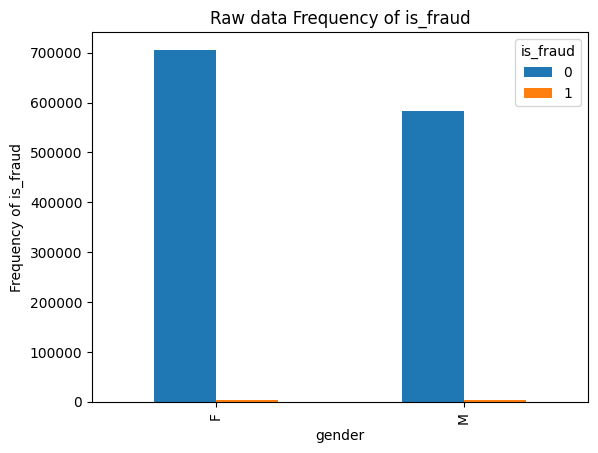

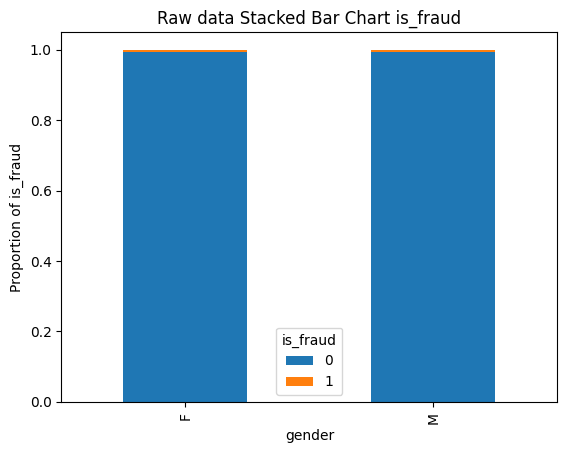

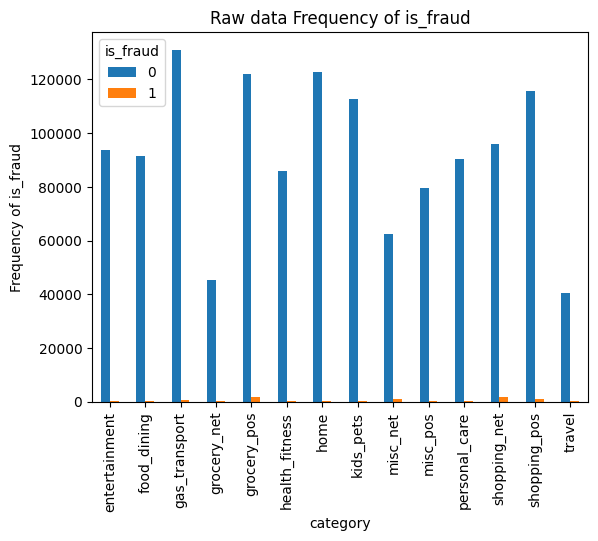

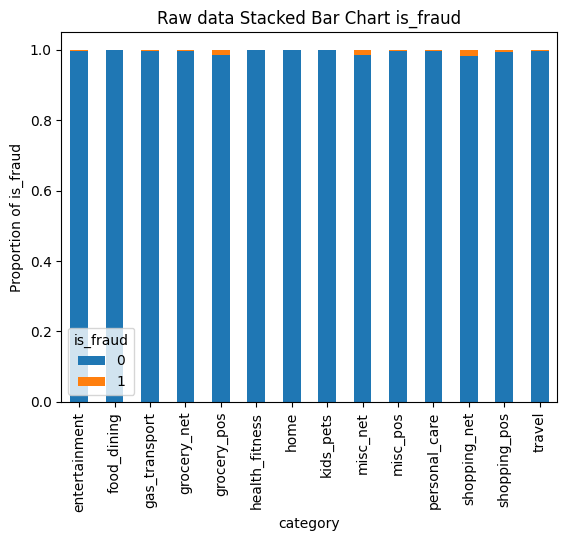

In [8]:
 ml.eda_categorical(df,['gender','category'],target,'Raw data')

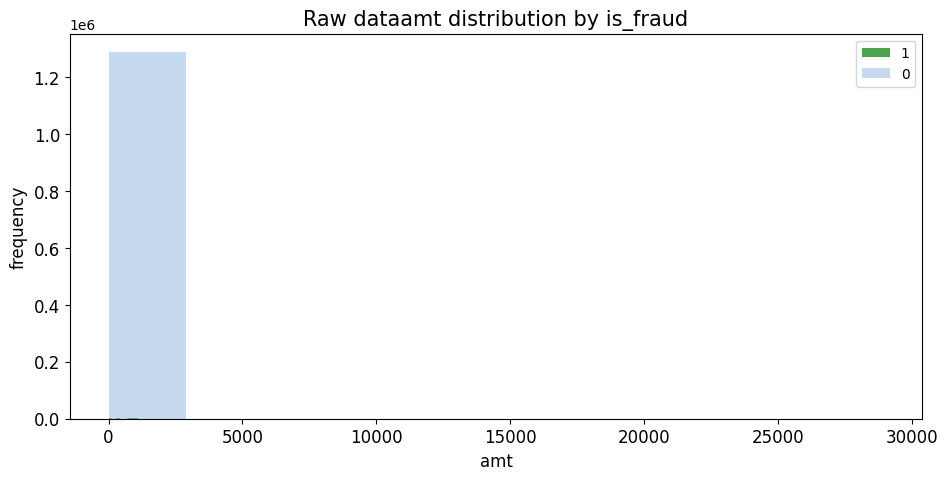

In [9]:
ml.eda_histogram(df,target,['amt'],'Raw data')

amt


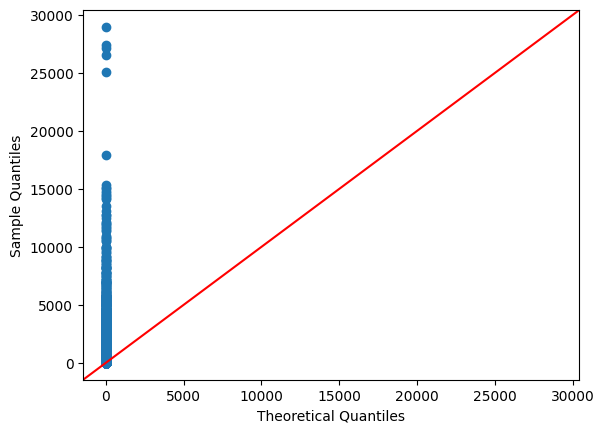

In [11]:
ml.eda_qq_plots(df,['amt'])